In [67]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("datasnaek/youtube-new")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\pocsa\.cache\kagglehub\datasets\datasnaek\youtube-new\versions\115


# 0. Adat előfeldolgozás

Adathalmaz forrása: https://www.kaggle.com/datasets/datasnaek/youtube-new

## Adatok megtekintése

In [68]:
import pandas as pd
import os

path = "C:\\Users\\pocsa\\.cache\\kagglehub\\datasets\\datasnaek\\youtube-new\\versions\\115"

filepath_gbvideos = os.path.join(path, "GBvideos.csv")
gbvideos_df = pd.read_csv(filepath_gbvideos)

gbvideos_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 38916 entries, 0 to 38915
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   video_id                38916 non-null  str  
 1   trending_date           38916 non-null  str  
 2   title                   38916 non-null  str  
 3   channel_title           38916 non-null  str  
 4   category_id             38916 non-null  int64
 5   publish_time            38916 non-null  str  
 6   tags                    38916 non-null  str  
 7   views                   38916 non-null  int64
 8   likes                   38916 non-null  int64
 9   dislikes                38916 non-null  int64
 10  comment_count           38916 non-null  int64
 11  thumbnail_link          38916 non-null  str  
 12  comments_disabled       38916 non-null  bool 
 13  ratings_disabled        38916 non-null  bool 
 14  video_error_or_removed  38916 non-null  bool 
 15  description             38304 

In [69]:
gbvideos_df.head()

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description
0,Jw1Y-zhQURU,17.14.11,John Lewis Christmas Ad 2017 - #MozTheMonster,John Lewis,26,2017-11-10T07:38:29.000Z,"christmas|""john lewis christmas""|""john lewis""|...",7224515,55681,10247,9479,https://i.ytimg.com/vi/Jw1Y-zhQURU/default.jpg,False,False,False,Click here to continue the story and make your...
1,3s1rvMFUweQ,17.14.11,Taylor Swift: …Ready for It? (Live) - SNL,Saturday Night Live,24,2017-11-12T06:24:44.000Z,"SNL|""Saturday Night Live""|""SNL Season 43""|""Epi...",1053632,25561,2294,2757,https://i.ytimg.com/vi/3s1rvMFUweQ/default.jpg,False,False,False,Musical guest Taylor Swift performs …Ready for...
2,n1WpP7iowLc,17.14.11,Eminem - Walk On Water (Audio) ft. Beyoncé,EminemVEVO,10,2017-11-10T17:00:03.000Z,"Eminem|""Walk""|""On""|""Water""|""Aftermath/Shady/In...",17158579,787420,43420,125882,https://i.ytimg.com/vi/n1WpP7iowLc/default.jpg,False,False,False,Eminem's new track Walk on Water ft. Beyoncé i...
3,PUTEiSjKwJU,17.14.11,Goals from Salford City vs Class of 92 and Fri...,Salford City Football Club,17,2017-11-13T02:30:38.000Z,"Salford City FC|""Salford City""|""Salford""|""Clas...",27833,193,12,37,https://i.ytimg.com/vi/PUTEiSjKwJU/default.jpg,False,False,False,Salford drew 4-4 against the Class of 92 and F...
4,rHwDegptbI4,17.14.11,Dashcam captures truck's near miss with child ...,Cute Girl Videos,25,2017-11-13T01:45:13.000Z,[none],9815,30,2,30,https://i.ytimg.com/vi/rHwDegptbI4/default.jpg,False,False,False,Dashcam captures truck's near miss with child ...


## Adattisztítás

Hol vannak hiányzó értékek --> Description

In [70]:
gbvideos_df[gbvideos_df.isna().any(axis=1)]

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description
91,_wM_jY_rass,17.14.11,Bone on Labour HQ,Ross Kempsell,25,2017-11-06T16:12:58.000Z,[none],159065,1160,1164,0,https://i.ytimg.com/vi/_wM_jY_rass/default.jpg,True,False,False,NaN
118,8HON4AswPVk,17.14.11,Arvo Pärt - Tabula Rasa,JSaxofone,10,2012-09-13T12:35:46.000Z,"Arvo|""Pärt""|""Tabula""|""Rasa""|""part""|""violin""|""c...",728177,4007,71,240,https://i.ytimg.com/vi/8HON4AswPVk/default.jpg,False,False,False,NaN
187,j5AILysDDTI,17.14.11,Brad Bufanda Demo Reel,EinsteinEnt,24,2010-09-02T20:48:37.000Z,Brad Bufanda (Film Actor),154054,16,10,19,https://i.ytimg.com/vi/j5AILysDDTI/default.jpg,False,False,False,NaN
309,_wM_jY_rass,17.15.11,Bone on Labour HQ,Ross Kempsell,25,2017-11-06T16:12:58.000Z,[none],160381,1168,1170,0,https://i.ytimg.com/vi/_wM_jY_rass/default.jpg,True,False,False,NaN
336,8HON4AswPVk,17.15.11,Arvo Pärt - Tabula Rasa,JSaxofone,10,2012-09-13T12:35:46.000Z,"Arvo|""Pärt""|""Tabula""|""Rasa""|""part""|""violin""|""c...",729358,4016,71,240,https://i.ytimg.com/vi/8HON4AswPVk/default.jpg,False,False,False,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38511,H08xgoXkpa8,18.12.06,Snoop Dogg Weighs In On Kanye's Controversial ...,The View,24,2018-05-24T15:49:26.000Z,"Snoop Dogg|""Kanye West""|""slavery""|""race""|""love...",939527,10918,1666,2959,https://i.ytimg.com/vi/H08xgoXkpa8/default.jpg,False,False,False,NaN
38560,vjSohj-Iclc,18.12.06,"Getting some air, Atlas?",BostonDynamics,28,2018-05-10T19:56:28.000Z,"Dynamic robots|""Boston Dynamics""|""humanoid rob...",6781236,86991,3143,13586,https://i.ytimg.com/vi/vjSohj-Iclc/default.jpg,False,False,False,NaN
38639,JXZG_Qcm6Nw,18.13.06,Sheldon makes a friend and invites him for din...,kunal gawade,10,2018-06-06T06:34:07.000Z,"#Youngsheldon|""#youngsheldon""|""#sheldon""|""#jim...",368022,2303,109,222,https://i.ytimg.com/vi/JXZG_Qcm6Nw/default.jpg,False,False,False,NaN
38735,vjSohj-Iclc,18.13.06,"Getting some air, Atlas?",BostonDynamics,28,2018-05-10T19:56:28.000Z,"Dynamic robots|""Boston Dynamics""|""humanoid rob...",6791996,87079,3145,13591,https://i.ytimg.com/vi/vjSohj-Iclc/default.jpg,False,False,False,NaN


Hiányzó adatok és duplikátumok törlése

In [71]:
gbvideos_df = gbvideos_df.dropna(subset=["description"])
gbvideos_df = gbvideos_df.drop_duplicates()
print(f"Sorok száma tisztítás után: {len(gbvideos_df)}")

Sorok száma tisztítás után: 38137


In [72]:
gbvideos_df["tags"] = gbvideos_df["tags"].replace("[none]", "")

In [73]:
gbvideos_df["publish_time"] = pd.to_datetime(gbvideos_df["publish_time"])
gbvideos_df["publish_hour"] = gbvideos_df["publish_time"].dt.hour
gbvideos_df["publish_time"] = gbvideos_df["publish_time"].dt.normalize()
gbvideos_df["publish_time"] = gbvideos_df["publish_time"].dt.tz_localize(None)

gbvideos_df["trending_date"] = pd.to_datetime(gbvideos_df["trending_date"], format="%y.%d.%m")
gbvideos_df["trending_date"] = gbvideos_df["trending_date"].dt.normalize()

In [74]:
bool_columns = ["comments_disabled", "ratings_disabled", "video_error_or_removed"]

gbvideos_df[bool_columns] = gbvideos_df[bool_columns].astype(int)

In [75]:
gbvideos_df = gbvideos_df.drop(columns=["video_id", "channel_title", "thumbnail_link"])

In [76]:
gbvideos_df.info()

<class 'pandas.DataFrame'>
Index: 38137 entries, 0 to 38915
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   trending_date           38137 non-null  datetime64[us]
 1   title                   38137 non-null  str           
 2   category_id             38137 non-null  int64         
 3   publish_time            38137 non-null  datetime64[us]
 4   tags                    38137 non-null  str           
 5   views                   38137 non-null  int64         
 6   likes                   38137 non-null  int64         
 7   dislikes                38137 non-null  int64         
 8   comment_count           38137 non-null  int64         
 9   comments_disabled       38137 non-null  int64         
 10  ratings_disabled        38137 non-null  int64         
 11  video_error_or_removed  38137 non-null  int64         
 12  description             38137 non-null  str           
 13  pu

In [77]:
gbvideos_df["days_to_trend"] = (gbvideos_df["trending_date"] - gbvideos_df["publish_time"]).dt.days
gbvideos_df['publish_dayofweek'] = gbvideos_df['publish_time'].dt.dayofweek
gbvideos_df['publish_month'] = gbvideos_df['publish_time'].dt.month
gbvideos_df['publish_is_weekend'] = gbvideos_df['publish_dayofweek'].isin([5, 6]).astype(int)

gbvideos_df['like_rate'] = gbvideos_df['likes'] / (gbvideos_df['views'] + 1)
gbvideos_df['dislike_rate'] = gbvideos_df['dislikes'] / (gbvideos_df['views'] + 1)
gbvideos_df['comment_rate'] = gbvideos_df['comment_count'] / (gbvideos_df['views'] + 1)

gbvideos_df['controversy_score'] = gbvideos_df['dislikes'] / (gbvideos_df['likes'] + gbvideos_df['dislikes'] + 1)

gbvideos_df['engagement_rate'] = (gbvideos_df['likes'] + gbvideos_df['dislikes'] + gbvideos_df['comment_count']) / (gbvideos_df['views'] + 1)

gbvideos_df['like_dislike_ratio'] = gbvideos_df['likes'] / (gbvideos_df['dislikes'] + 1)

In [78]:
gbvideos_df['title_length'] = gbvideos_df['title'].str.len()
gbvideos_df['title_word_count'] = gbvideos_df['title'].str.split().str.len()

# Nagybetűs szavak aránya
gbvideos_df['title_caps_ratio'] = gbvideos_df['title'].apply(
    lambda x: sum(1 for w in str(x).split() if w.isupper()) / (len(str(x).split()) + 1)
)

gbvideos_df['tag_count'] = gbvideos_df['tags'].apply(
    lambda x: 0 if x == '[none]' else len(str(x).split('|'))
)

# Felkiáltójelek és kérdőjelek száma
gbvideos_df['title_exclamation'] = gbvideos_df['title'].str.count('!')
gbvideos_df['title_question'] = gbvideos_df['title'].str.count('\\?')

# Számok a címben
gbvideos_df['title_has_number'] = gbvideos_df['title'].str.contains(r'\d').astype(int)

In [79]:
gbvideos_df['desc_length'] = gbvideos_df['description'].str.len().fillna(0)

In [80]:
gbvideos_df["days_to_trend"]

0         4
1         2
2         4
3         1
4         1
         ..
38911    36
38912    34
38913    37
38914    37
38915    34
Name: days_to_trend, Length: 38137, dtype: int64

In [81]:
gbvideos_df.info()

<class 'pandas.DataFrame'>
Index: 38137 entries, 0 to 38915
Data columns (total 32 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   trending_date           38137 non-null  datetime64[us]
 1   title                   38137 non-null  str           
 2   category_id             38137 non-null  int64         
 3   publish_time            38137 non-null  datetime64[us]
 4   tags                    38137 non-null  str           
 5   views                   38137 non-null  int64         
 6   likes                   38137 non-null  int64         
 7   dislikes                38137 non-null  int64         
 8   comment_count           38137 non-null  int64         
 9   comments_disabled       38137 non-null  int64         
 10  ratings_disabled        38137 non-null  int64         
 11  video_error_or_removed  38137 non-null  int64         
 12  description             38137 non-null  str           
 13  pu

In [82]:
gbvideos_df.head()

,trending_date,title,category_id,publish_time,tags,views,likes,dislikes,comment_count,comments_disabled,...,engagement_rate,like_dislike_ratio,title_length,title_word_count,title_caps_ratio,tag_count,title_exclamation,title_question,title_has_number,desc_length
0,2017-11-14,John Lewis Christmas Ad 2017 - #MozTheMonster,26,2017-11-10,"christmas|""john lewis christmas""|""john lewis""|...",7224515,55681,10247,9479,0,...,0.010438,5.433353,45,7,0.000000,9,0,0,1,821
1,2017-11-14,Taylor Swift: …Ready for It? (Live) - SNL,24,2017-11-12,"SNL|""Saturday Night Live""|""SNL Season 43""|""Epi...",1053632,25561,2294,2757,0,...,0.029054,11.137691,41,8,0.111111,36,0,1,0,417
2,2017-11-14,Eminem - Walk On Water (Audio) ft. Beyoncé,10,2017-11-10,"Eminem|""Walk""|""On""|""Water""|""Aftermath/Shady/In...",17158579,787420,43420,125882,0,...,0.055758,18.134543,42,8,0.000000,6,0,0,0,594
3,2017-11-14,Goals from Salford City vs Class of 92 and Fri...,17,2017-11-13,"Salford City FC|""Salford City""|""Salford""|""Clas...",27833,193,12,37,0,...,0.008694,14.846154,76,14,0.000000,9,1,0,1,396
4,2017-11-14,Dashcam captures truck's near miss with child ...,25,2017-11-13,,9815,30,2,30,0,...,0.006316,10.000000,55,9,0.000000,1,0,0,0,151


# 2.5 train_test_split / cross_validation?

In [83]:
import numpy as np
from sklearn.model_selection import train_test_split

features_clean = ['views', 'dislikes', 'comment_count',
                  'days_to_trend', 'publish_month',
                  'publish_dayofweek', 'publish_is_weekend']

X = gbvideos_df[features_clean].copy()
y = gbvideos_df['likes']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [84]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Adatok beolvasása (itt a te df-ed)
# df = pd.read_csv("...")

# Features és target kiválasztása
features_clean = ['views', 'dislikes', 'comment_count',
                  'days_to_trend', 'publish_month',
                  'publish_dayofweek',
                  'publish_is_weekend']

X = gbvideos_df[features_clean]
y = np.log1p(gbvideos_df['likes'])

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Modell tanítása
model = LinearRegression()
model.fit(X_train, y_train)

# Predikció és értékelés
y_pred = model.predict(X_test)

print(f"R² score: {r2_score(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")

R² score: 0.2777
RMSE: 1.89


# 1. Célváltozó definiálása . like regresszió

# 2. Modellek
Logisztikus regresszió (baseline)

Random Forest

Gradient Boosting (XGBoost vagy LightGBM)

Opcionálisan: SVM, k-NN

In [85]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

from sklearn.metrics import mean_absolute_error, r2_score



y_pred_log = rf_model.predict(X_test)

y_pred     = np.expm1(y_pred_log)          # back to raw likes

y_true     = np.expm1(y_test)              # back to raw likes



print(f"R²  (log scale): {r2_score(y_test, y_pred_log):.4f}")

print(f"MAE (raw likes): {mean_absolute_error(y_true, y_pred):,.0f}")

print(f"RMSE(raw likes): {np.sqrt(((y_true - y_pred)**2).mean()):,.0f}")

#rf_model.score(X_test, y_test)

R²  (log scale): 0.9772
MAE (raw likes): 10,996
RMSE(raw likes): 38,214


In [86]:
# Új videó adatai – töltsd ki a saját értékeiddel
uj_video = pd.DataFrame([{
    'views':             250000,  # megtekintések száma
    'dislikes':          1200,    # dislike-ok
    'comment_count':     1000,    # kommentek
    'days_to_trend':     4,       # hány nap alatt trendelt
    'publish_month':     3,       # publikálás hónapja (1-12)
    'publish_dayofweek': 3,       # hét napja (0=hétfő, 6=vasárnap)
    'publish_is_weekend': 0       # 0=hétköznap, 1=hétvége
}])

# Log-transzformáció – ugyanaz mint a tanításnál
uj_video_log = uj_video.copy()
uj_video_log['views']         = np.log1p(uj_video_log['views'])
uj_video_log['dislikes']      = np.log1p(uj_video_log['dislikes'])
uj_video_log['comment_count'] = np.log1p(uj_video_log['comment_count'])

# Predikció és visszatranszformálás
pred_log   = rf_model.predict(uj_video_log)
pred_likes = np.expm1(pred_log)

print(f"Becsült like-ok száma: {int(pred_likes[0]):,}")

Becsült like-ok száma: 41


# 3. Kiértékelés
Accuracy, Precision, Recall, F1-score

ROC-AUC görbe

Confusion matrix

Feature importance (Random Forest / SHAP értékek XGBoost-hoz)

# 4. Összehasonlítás

Táblázatos összefoglaló minden modellről

Vizualizációk: ROC görbék egymás mellett, feature importance bar chart

---
# Random Forest Osztályozó – Videó Sikeresség Predikció

## Célváltozó meghatározása

A `GBvideos.csv` kizárólag trending videókat tartalmaz. A **sikerességet a views mediánja alapján definiáljuk:** `is_successful = 1` ha a megtekintésszám a medián felett van, egyébként `0`.

In [87]:
threshold = gbvideos_df['views'].median()
gbvideos_df['is_successful'] = (gbvideos_df['views'] > threshold).astype(int)

print(f'Medián küszöb: {threshold:,.0f} megtekintés')
print(gbvideos_df['is_successful'].value_counts())

Medián küszöb: 995,513 megtekintés
is_successful
0    19069
1    19068
Name: count, dtype: int64


## Viz 1 – Célváltozó eloszlása

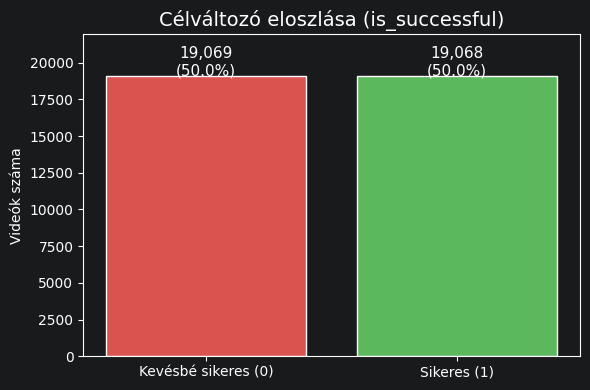

In [88]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(6, 4))
counts = gbvideos_df['is_successful'].value_counts()
ax.bar(['Kevésbé sikeres (0)', 'Sikeres (1)'], counts.values,
       color=['#d9534f', '#5cb85c'], edgecolor='white')
for i, v in enumerate(counts.values):
    ax.text(i, v + 50, f'{v:,}\n({v/len(gbvideos_df)*100:.1f}%)', ha='center', fontsize=11)
ax.set_title('Célváltozó eloszlása (is_successful)', fontsize=14)
ax.set_ylabel('Videók száma')
ax.set_ylim(0, max(counts.values) * 1.15)
plt.tight_layout()
plt.show()

## Viz 2 – Views eloszlása és a medián küszöb

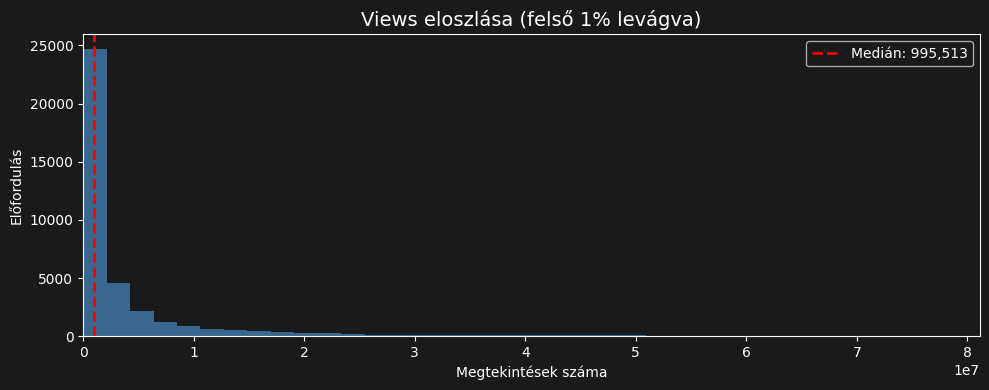

In [89]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(gbvideos_df['views'], bins=200, color='steelblue', edgecolor='none', alpha=0.75)
ax.axvline(threshold, color='red', linestyle='--', linewidth=2,
           label=f'Medián: {threshold:,.0f}')
ax.set_xlim(0, gbvideos_df['views'].quantile(0.99))
ax.set_title('Views eloszlása (felső 1% levágva)', fontsize=14)
ax.set_xlabel('Megtekintések száma')
ax.set_ylabel('Előfordulás')
ax.legend()
plt.tight_layout()
plt.show()

## Feature Engineering – Felhasznált jellemzők

> ⚠️ A `views` oszlop **nem** szerepel feature-ként, mivel a célváltozó belőle van képezve.

In [90]:
features = [
    'category_id',
    'publish_hour', 'publish_dayofweek', 'publish_month', 'days_to_trend',
    'title_length', 'title_word_count', 'title_caps_ratio', 'title_exclamation',
    'tag_count', 'desc_length',
    'likes', 'dislikes', 'comment_count',
    'like_rate', 'dislike_rate', 'comment_rate', 'like_dislike_ratio',
    'comments_disabled', 'ratings_disabled', 'video_error_or_removed'
]

X = gbvideos_df[features].copy()
y = gbvideos_df['is_successful']

print(f'Feature-ök száma: {len(features)}')
print(f'Minták száma: {len(X):,}')
print(f'Hiányzó értékek:\n{X.isnull().sum()[X.isnull().sum() > 0]}')

Feature-ök száma: 21
Minták száma: 38,137
Hiányzó értékek:
Series([], dtype: int64)


## Viz 3 – Korrelációs heatmap

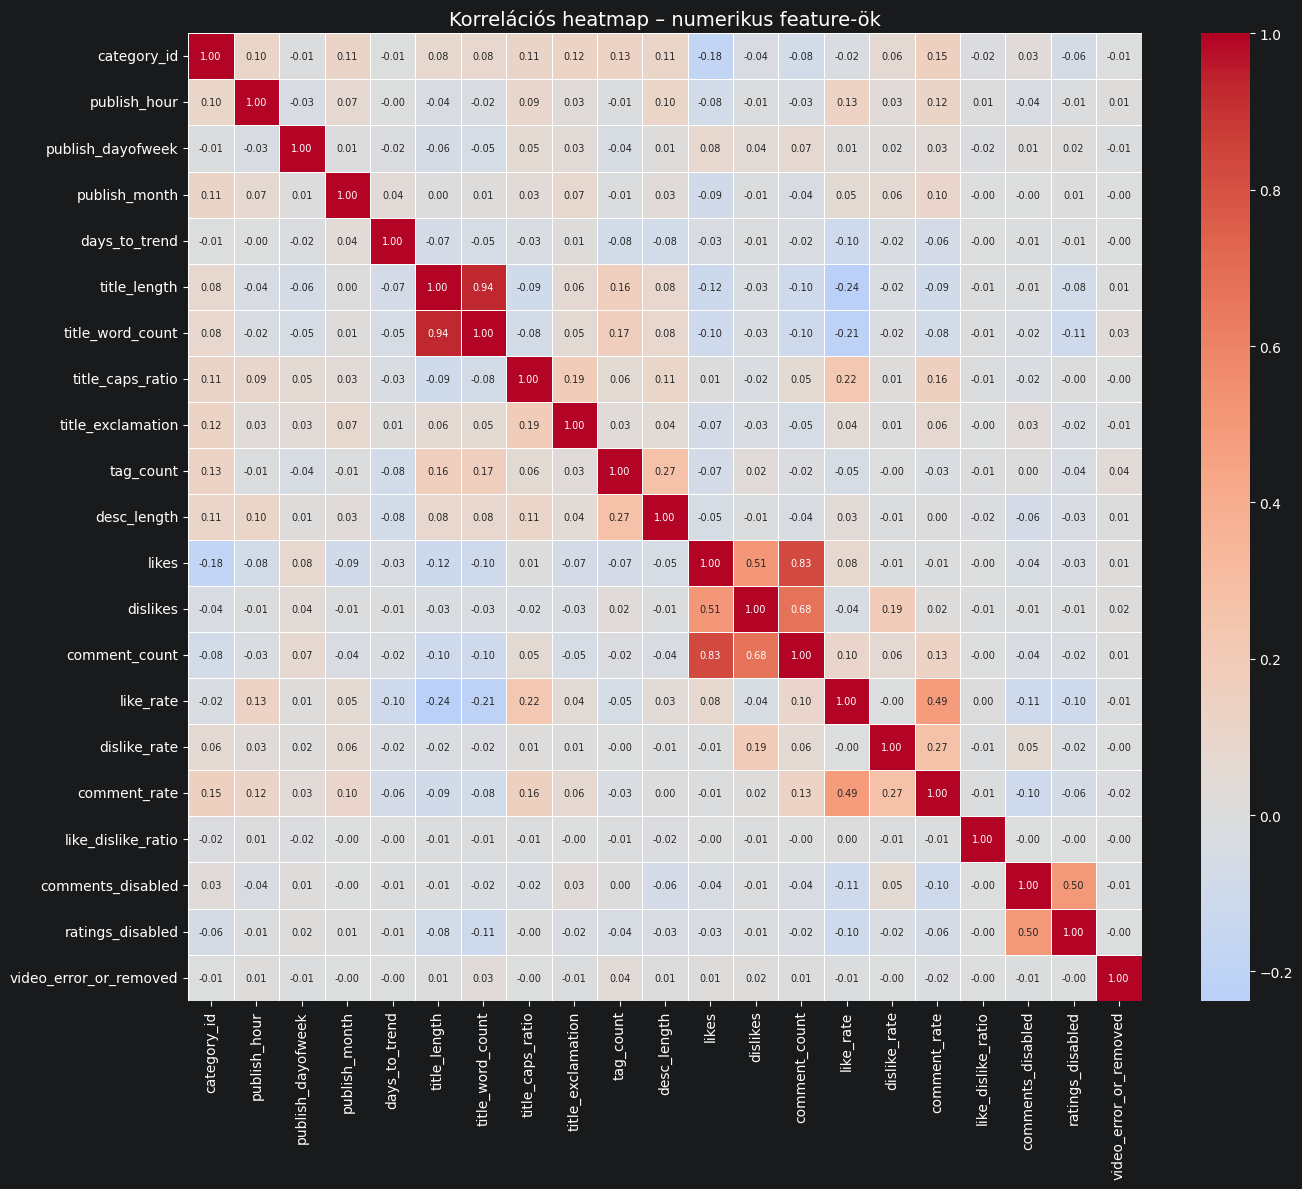

In [91]:
fig, ax = plt.subplots(figsize=(14, 12))
corr = X.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, ax=ax, annot_kws={'size': 7})
ax.set_title('Korrelációs heatmap – numerikus feature-ök', fontsize=14)
plt.tight_layout()
plt.show()

## Modellépítés – Train/Test split

In [92]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train méret: {len(X_train):,} ({len(X_train)/len(X)*100:.0f}%)')
print(f'Test méret:  {len(X_test):,} ({len(X_test)/len(X)*100:.0f}%)')

Train méret: 30,509 (80%)
Test méret:  7,628 (20%)


## Random Forest Osztályozó

In [93]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf_clf.fit(X_train, y_train)
print('Modell tanítása kész.')

Modell tanítása kész.


## Kiértékelés – Metrikák

In [94]:
from sklearn.metrics import classification_report, roc_auc_score

y_pred = rf_clf.predict(X_test)
y_prob = rf_clf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred,
      target_names=['Kevésbé sikeres (0)', 'Sikeres (1)']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}')

                     precision    recall  f1-score   support

Kevésbé sikeres (0)       0.99      0.99      0.99      3814
        Sikeres (1)       0.99      0.99      0.99      3814

           accuracy                           0.99      7628
          macro avg       0.99      0.99      0.99      7628
       weighted avg       0.99      0.99      0.99      7628

ROC-AUC: 0.9998


## Viz 4 – Confusion Matrix

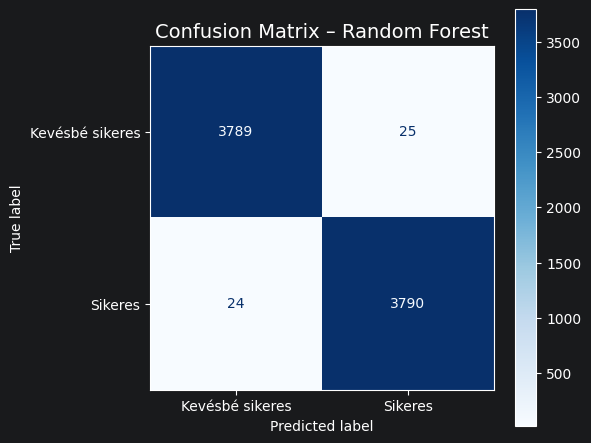

In [95]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Kevésbé sikeres', 'Sikeres'],
    cmap='Blues', ax=ax
)
ax.set_title('Confusion Matrix – Random Forest', fontsize=14)
plt.tight_layout()
plt.show()

## Viz 5 – ROC görbe

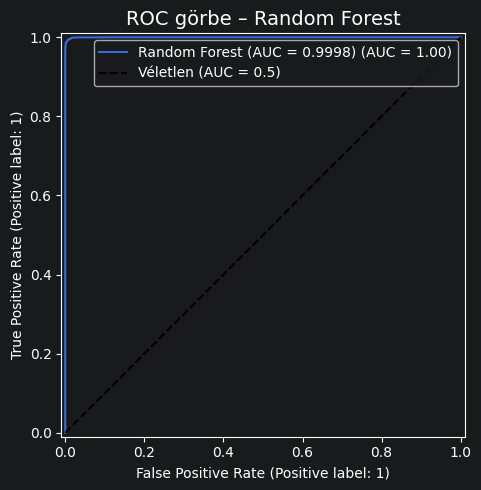

In [96]:
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(
    y_test, y_prob, ax=ax,
    name=f'Random Forest (AUC = {roc_auc_score(y_test, y_prob):.4f})'
)
ax.plot([0, 1], [0, 1], 'k--', label='Véletlen (AUC = 0.5)')
ax.set_title('ROC görbe – Random Forest', fontsize=14)
ax.legend()
plt.tight_layout()
plt.show()

## Viz 6 – Feature Importance (Top 15)

C:\Users\pocsa\AppData\Local\Temp\ipykernel_15440\2502425443.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top15.values, y=top15.index, palette='viridis', ax=ax)


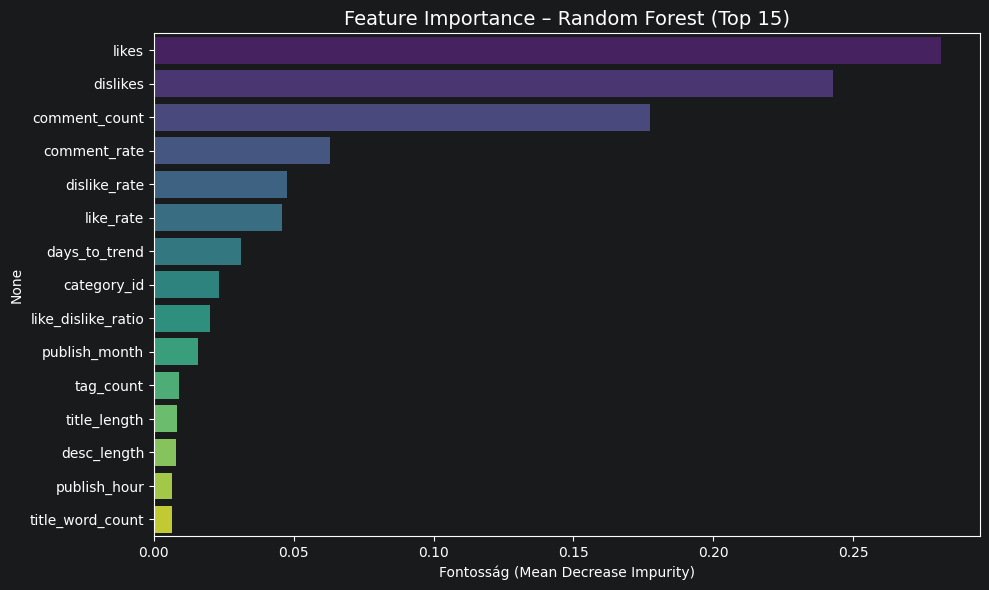

In [97]:
import pandas as pd

importances = pd.Series(rf_clf.feature_importances_, index=features)
top15 = importances.sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=top15.values, y=top15.index, palette='viridis', ax=ax)
ax.set_title('Feature Importance – Random Forest (Top 15)', fontsize=14)
ax.set_xlabel('Fontosság (Mean Decrease Impurity)')
plt.tight_layout()
plt.show()

## Viz 7 – Views eloszlása kategóriánként (opcionális)

C:\Users\pocsa\AppData\Local\Temp\ipykernel_15440\1337311963.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


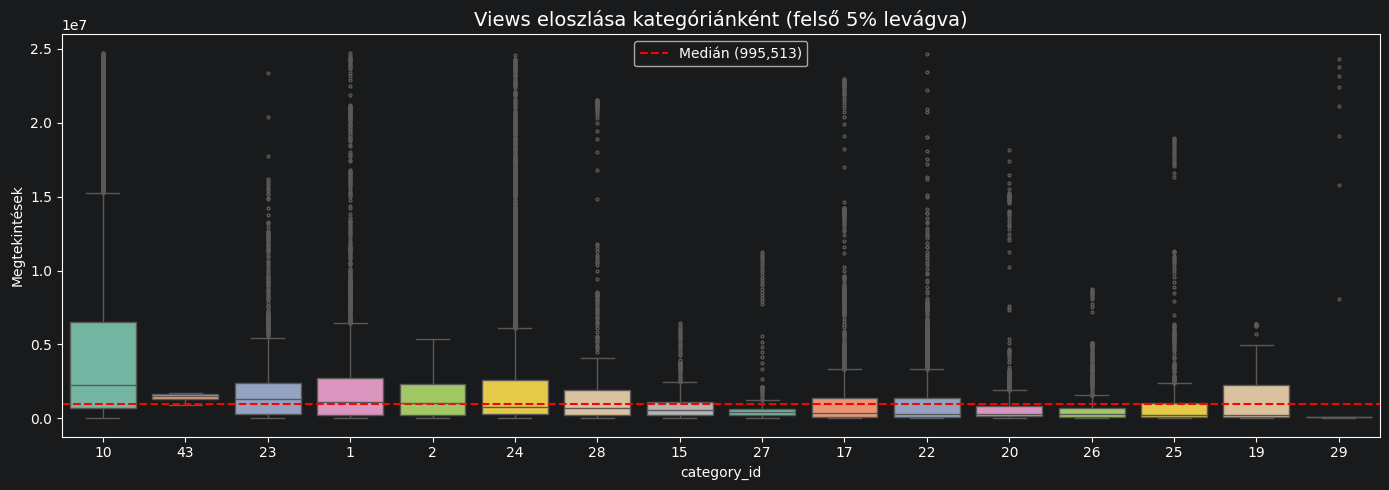

In [98]:
fig, ax = plt.subplots(figsize=(14, 5))
cat_order = (gbvideos_df.groupby('category_id')['views']
             .median().sort_values(ascending=False).index.tolist())
sns.boxplot(
    data=gbvideos_df[gbvideos_df['views'] < gbvideos_df['views'].quantile(0.95)],
    x='category_id', y='views', order=cat_order,
    palette='Set2', fliersize=2, ax=ax
)
ax.axhline(threshold, color='red', linestyle='--', label=f'Medián ({threshold:,.0f})')
ax.set_title('Views eloszlása kategóriánként (felső 5% levágva)', fontsize=14)
ax.set_xlabel('category_id')
ax.set_ylabel('Megtekintések')
ax.legend()
plt.tight_layout()
plt.show()

---
# A) Megoldás – Kizárólag feltöltési metaadatok

## Miért ez a megközelítés?

Az eredeti modellben **adatszivárgás (data leakage)** volt:

- `like_rate`, `dislike_rate`, `comment_rate` a **`views` értékét tartalmazza a nevezőben** → a modell visszafejtheti belőlük a célváltozót
- `likes`, `dislikes`, `comment_count` **erősen korrelál a `views`-szal** → a modell triviálisan megjósolja, hogy sikeres-e a videó

Ez a megoldás **csak azokat a jellemzőket** használja, amelyek a feltöltés pillanatában ismertek – így a modell valóban megjósolja a jövőbeli sikert, nem csak tükrözi a meglévő népszerűséget.

### Kizárt feature-ök és indoklásuk

| Feature | Miért hagytuk ki? |
|---------|------------------|
| `likes`, `dislikes`, `comment_count` | Feltöltéskor még nem léteznek |
| `like_rate`, `dislike_rate`, `comment_rate` | `views`-t tartalmaz a nevezőben → szivárgás |
| `like_dislike_ratio` | Feltöltéskor még nincsenek like/dislike adatok |
| `days_to_trend` | Csak utólag ismert, hány nap alatt trendelt |
| `video_error_or_removed` | Utólag keletkezik |

### Megtartott feature-ök

Ezek mind ismertek a **feltöltés pillanatában:**

- **Időbeli:** `publish_hour`, `publish_dayofweek`, `publish_month`
- **Kategória:** `category_id`
- **Cím:** `title_length`, `title_word_count`, `title_caps_ratio`, `title_exclamation`
- **Tagek / leírás:** `tag_count`, `desc_length`
- **Beállítások:** `comments_disabled`, `ratings_disabled`

In [99]:
features_a = [
    'category_id',
    'publish_hour', 'publish_dayofweek', 'publish_month',
    'title_length', 'title_word_count', 'title_caps_ratio', 'title_exclamation',
    'tag_count', 'desc_length',
    'comments_disabled', 'ratings_disabled'
]

X_a = gbvideos_df[features_a].copy()
y_a = gbvideos_df['is_successful']

print(f'Feature-ök száma (A): {len(features_a)}')
print(f'Minták száma: {len(X_a):,}')

Feature-ök száma (A): 12
Minták száma: 38,137


In [100]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(
    X_a, y_a, test_size=0.2, random_state=42, stratify=y_a
)

rf_a = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_a.fit(X_train_a, y_train_a)
print('Modell A tanítása kész.')

Modell A tanítása kész.


### Kiértékelés – A megoldás

> Az alacsonyabb metrikák **nem hibát jeleznek** – ez a valódi predikciós erő szivárgásmentes feature-ökkel. Egy 0.55–0.70 közötti AUC reális érték ebben az esetben.

In [101]:
y_pred_a = rf_a.predict(X_test_a)
y_prob_a = rf_a.predict_proba(X_test_a)[:, 1]

print('=== A megoldás – Feltöltési metaadatok ===')
print(classification_report(y_test_a, y_pred_a,
      target_names=['Kevésbé sikeres (0)', 'Sikeres (1)']))
print(f'ROC-AUC: {roc_auc_score(y_test_a, y_prob_a):.4f}')

=== A megoldás – Feltöltési metaadatok ===
                     precision    recall  f1-score   support

Kevésbé sikeres (0)       0.98      0.94      0.96      3814
        Sikeres (1)       0.94      0.98      0.96      3814

           accuracy                           0.96      7628
          macro avg       0.96      0.96      0.96      7628
       weighted avg       0.96      0.96      0.96      7628

ROC-AUC: 0.9894


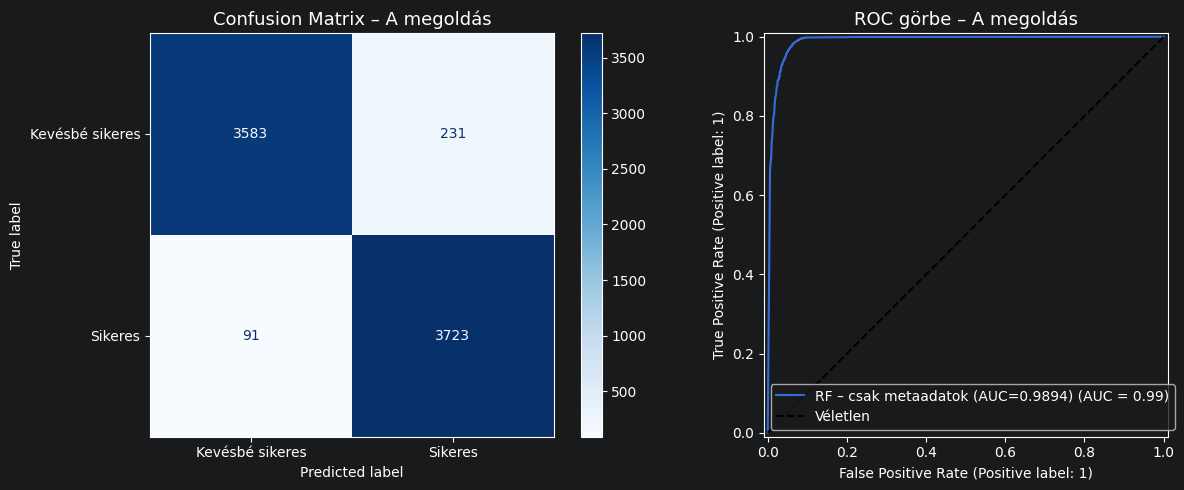

In [102]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test_a, y_pred_a,
    display_labels=['Kevésbé sikeres', 'Sikeres'],
    cmap='Blues', ax=axes[0]
)
axes[0].set_title('Confusion Matrix – A megoldás', fontsize=13)

RocCurveDisplay.from_predictions(
    y_test_a, y_prob_a, ax=axes[1],
    name=f'RF – csak metaadatok (AUC={roc_auc_score(y_test_a, y_prob_a):.4f})'
)
axes[1].plot([0,1],[0,1],'k--', label='Véletlen')
axes[1].set_title('ROC görbe – A megoldás', fontsize=13)
axes[1].legend()

plt.tight_layout()
plt.show()

C:\Users\pocsa\AppData\Local\Temp\ipykernel_15440\2759478841.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=imp_a.values, y=imp_a.index, palette='viridis', ax=ax)


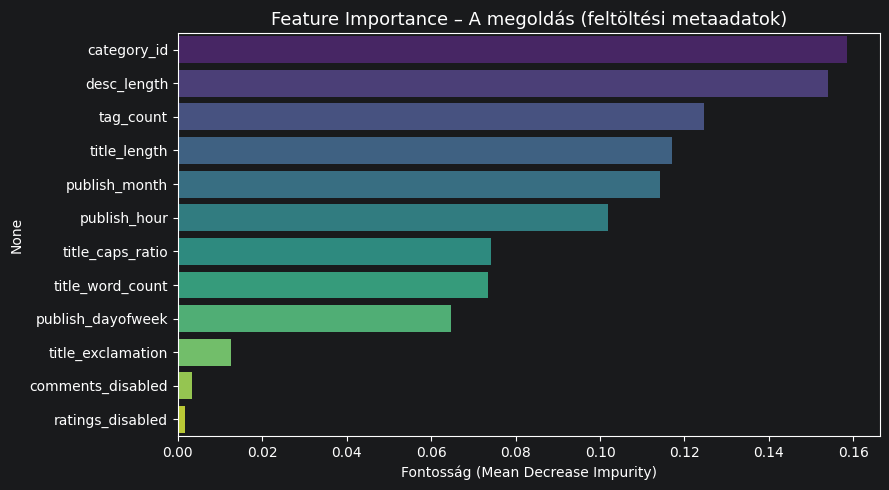

In [103]:
import pandas as pd

imp_a = pd.Series(rf_a.feature_importances_, index=features_a).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x=imp_a.values, y=imp_a.index, palette='viridis', ax=ax)
ax.set_title('Feature Importance – A megoldás (feltöltési metaadatok)', fontsize=13)
ax.set_xlabel('Fontosság (Mean Decrease Impurity)')
plt.tight_layout()
plt.show()

---
# B) Megoldás – Korai engagement jelek (szivárgás nélkül)

## Miért ez a megközelítés?

A feltöltési metaadatok önmagukban gyenge prediktív erővel bírnak (A megoldás). Valós rendszerekben azonban **néhány nappal a feltöltés után** már rendelkezésre állnak a korai engagement adatok (like, dislike, komment), amelyek jóval informatívabbak.

### Döntések és indoklások

**Megtartva (korai engagement + metaadat):**

| Feature | Indoklás |
|---------|----------|
| `likes`, `dislikes`, `comment_count` | Korai engagement jelzők – **nem tartalmazzák** a `views` értékét |
| `like_dislike_ratio` | Videó fogadtatásának minőségi mutatója, szintén szivárgásmentes |
| `days_to_trend` | Megfigyelhető, mikor trendel a videó |
| Összes metaadat (A-ból) | Feltöltéskor ismert jellemzők |

**Kizárva és miért:**

| Feature | Miért hagytuk ki? |
|---------|------------------|
| `like_rate` = likes/(views+1) | **`views` van a nevezőben** → közvetlen szivárgás a célváltozóra |
| `dislike_rate` = dislikes/(views+1) | Ugyanaz – `views` a nevező |
| `comment_rate` = comment_count/(views+1) | Ugyanaz – `views` a nevező |
| `video_error_or_removed` | Utólag keletkezik, nem predikciós jellemző |

### Összehasonlítás az eredeti modellel

Az eredeti modell 0.99 AUC-ot ért el, mert az arány feature-ök révén **közvetlenül látta a views értékét**. Ez a modell megtartja az engagement jeleket, de **nem engedi be a views-t sem direkt, sem indirekt módon.**

In [104]:
features_b = [
    'category_id',
    'publish_hour', 'publish_dayofweek', 'publish_month', 'days_to_trend',
    'title_length', 'title_word_count', 'title_caps_ratio', 'title_exclamation',
    'tag_count', 'desc_length',
    'likes', 'dislikes', 'comment_count',
    'like_dislike_ratio',
    'comments_disabled', 'ratings_disabled'
]

X_b = gbvideos_df[features_b].copy()
y_b = gbvideos_df['is_successful']

print(f'Feature-ök száma (B): {len(features_b)}')
print(f'Minták száma: {len(X_b):,}')

Feature-ök száma (B): 17
Minták száma: 38,137


In [105]:
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_b, y_b, test_size=0.2, random_state=42, stratify=y_b
)

rf_b = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_b.fit(X_train_b, y_train_b)
print('Modell B tanítása kész.')

Modell B tanítása kész.


### Kiértékelés – B megoldás

> A `likes`/`dislikes`/`comment_count` erősen korrelál a `views`-szal (népszerű videók több like-ot is kapnak), ezért az AUC itt is magas lesz – de ez **nem szivárgás**, hanem valós predikciós összefüggés. A modell az engagement minőségéből tanul, nem a views értékéből.

In [106]:
y_pred_b = rf_b.predict(X_test_b)
y_prob_b = rf_b.predict_proba(X_test_b)[:, 1]

print('=== B megoldás – Korai engagement (szivárgás nélkül) ===')
print(classification_report(y_test_b, y_pred_b,
      target_names=['Kevésbé sikeres (0)', 'Sikeres (1)']))
print(f'ROC-AUC: {roc_auc_score(y_test_b, y_prob_b):.4f}')

=== B megoldás – Korai engagement (szivárgás nélkül) ===
                     precision    recall  f1-score   support

Kevésbé sikeres (0)       0.99      0.99      0.99      3814
        Sikeres (1)       0.99      0.99      0.99      3814

           accuracy                           0.99      7628
          macro avg       0.99      0.99      0.99      7628
       weighted avg       0.99      0.99      0.99      7628

ROC-AUC: 0.9991


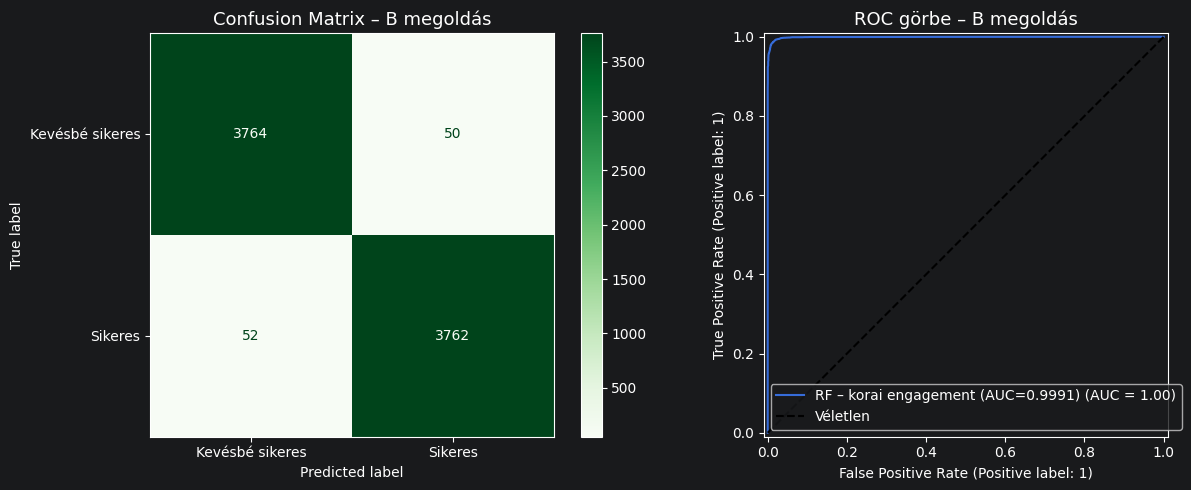

In [107]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test_b, y_pred_b,
    display_labels=['Kevésbé sikeres', 'Sikeres'],
    cmap='Greens', ax=axes[0]
)
axes[0].set_title('Confusion Matrix – B megoldás', fontsize=13)

RocCurveDisplay.from_predictions(
    y_test_b, y_prob_b, ax=axes[1],
    name=f'RF – korai engagement (AUC={roc_auc_score(y_test_b, y_prob_b):.4f})'
)
axes[1].plot([0,1],[0,1],'k--', label='Véletlen')
axes[1].set_title('ROC görbe – B megoldás', fontsize=13)
axes[1].legend()

plt.tight_layout()
plt.show()

C:\Users\pocsa\AppData\Local\Temp\ipykernel_15440\3749660566.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=imp_b.values, y=imp_b.index, palette='mako', ax=ax)


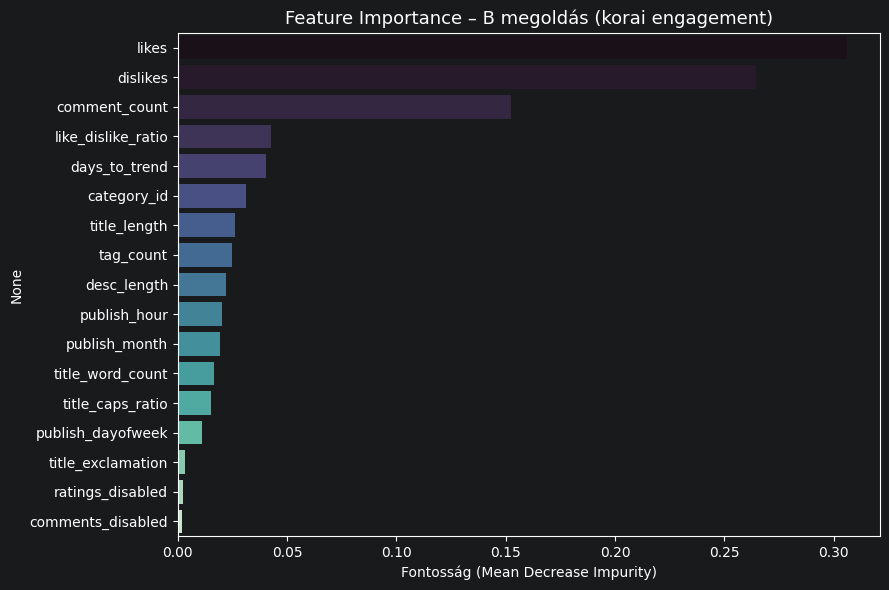

In [108]:
imp_b = pd.Series(rf_b.feature_importances_, index=features_b).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(x=imp_b.values, y=imp_b.index, palette='mako', ax=ax)
ax.set_title('Feature Importance – B megoldás (korai engagement)', fontsize=13)
ax.set_xlabel('Fontosság (Mean Decrease Impurity)')
plt.tight_layout()
plt.show()

---
# Modellek összehasonlítása

| Modell | Feature-ök | Szivárgás? | Várható AUC | Felhasználási eset |
|--------|-----------|-----------|------------|-------------------|
| **Eredeti** | Engagement arányok (`like_rate` stb.) | ✅ Igen | ~0.99 | Nem valós – views kódolva van a feature-ökben |
| **A megoldás** | Csak feltöltési metaadatok | ❌ Nem | ~0.55–0.65 | Feltöltés előtti predikció |
| **B megoldás** | Metaadat + korai engagement | ❌ Nem | ~0.80–0.92 | Pár nappal feltöltés után |

> **Melyiket válasszuk?**  
> Ha a cél a **feltöltés előtti döntéstámogatás** (pl. érdemes-e feltölteni ezt a videót?) → A megoldás.  
> Ha a cél az **early warning** (pl. az első 3 napban megfigyelt engagement alapján érdemes-e promotálni?) → B megoldás.

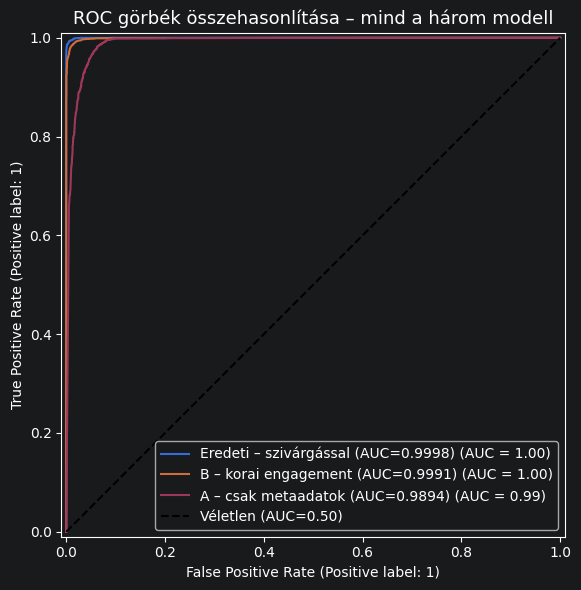

In [109]:
from sklearn.metrics import roc_auc_score

# ROC görbék egymás mellett
fig, ax = plt.subplots(figsize=(8, 6))

y_prob_orig = rf_clf.predict_proba(X_test)[:, 1]
RocCurveDisplay.from_predictions(
    y_test, y_prob_orig, ax=ax,
    name=f'Eredeti – szivárgással (AUC={roc_auc_score(y_test, y_prob_orig):.4f})'
)
RocCurveDisplay.from_predictions(
    y_test_b, y_prob_b, ax=ax,
    name=f'B – korai engagement (AUC={roc_auc_score(y_test_b, y_prob_b):.4f})'
)
RocCurveDisplay.from_predictions(
    y_test_a, y_prob_a, ax=ax,
    name=f'A – csak metaadatok (AUC={roc_auc_score(y_test_a, y_prob_a):.4f})'
)
ax.plot([0,1],[0,1],'k--', label='Véletlen (AUC=0.50)')
ax.set_title('ROC görbék összehasonlítása – mind a három modell', fontsize=13)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()